In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
from datetime import datetime


import sys
import os

In [2]:
# MAGIA (não mexer mt pfv)
def show_args(func):
    def wrapper(*args, **kwargs):
        arg_list = []

        # Prepare argument list
        for name, value in zip(func.__code__.co_varnames, args):
            if isinstance(value, pd.DataFrame):
                arg_list.append(f"{name}: DataFrame ({value.shape})")
            else:
                arg_list.append(f"{name}: {value}")
        for k, v in kwargs.items():
            if isinstance(v, pd.DataFrame):
                arg_list.append(f"{k}: DataFrame ({v.shape})")
            else:
                arg_list.append(f"{k}: {v}")

        print(f"Executando <{func.__name__}>\n({'\\n'.join(arg_list)})")

        # Measure execution time
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()

        print(f"Tempo de execução: {end - start:.6f} segundos\n")
        return result
    return wrapper

In [3]:
from pathlib import Path
import pandas as pd

@show_args
def csvs_to_parquet(input_folder, output_folder):
    input_path = Path(input_folder)
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    for csv_file in input_path.glob("*.csv"):
        try:
            df = pd.read_csv(csv_file, encoding="utf-8")
        except UnicodeDecodeError:
            df = pd.read_csv(csv_file, encoding="latin1")

        parquet_file = output_path / csv_file.with_suffix(".parquet").name
        df.to_parquet(parquet_file, index=False)



In [4]:
#csvs_to_parquet("../data/data/refined/csvs", "../data/data/refined/parquets")

In [5]:
articles_raw = pd.read_parquet('../data/data/refined/parquets/article.parquet').rename(columns={
    'eid': 'art_id',
    'subtype description': 'art_subtype',
    'title': 'art_title',
    'published date': 'art_published_date',
    'cited by count': 'art_citations',
    'source id' : 'art_source',
    'aggregation type' : 'art_source_type'
})[['art_id', 'art_subtype', 'art_title', 'art_published_date', 'art_citations', 'art_source', 'art_source_type']] # B

scores_raw = pd.read_parquet('../data/data/refined/parquets/CiteScore_2024_annual_values.parquet').rename(columns={
    'Scopus Source ID' : 'art_source',
    'Title' : 'src_title',
    'Citation Count' : 'src_citation_count',
    'CiteScore' : 'src_citescore',
    'Scopus Sub-Subject Area' : 'src_subject_area',
    'Percentile' : 'src_percentile',
    'RANK' : 'src_rank',
    'Rank Out Of' : 'src_rank_count',
    'Quartile' : 'src_quartile'
})[['art_source', 'src_title', 'src_citation_count', 'src_citescore', 'src_subject_area', 'src_percentile', 'src_rank', 'src_rank_count', 'src_quartile']]


authors_institutions_raw = pd.read_parquet('../data/data/refined/parquets/authors_institution.parquet').rename(columns={
    #eid,auid,creator,afid,dptid,organization,country,city
    'eid': 'art_id',
    'auid': 'aut_id',
    'creator': 'main_writer',
    'afid': 'ins_id',
    'dptid': 'dpt_id',
    'organization': 'ins_org',
    'country': 'ins_country',
    'city': 'ins_city'
})

institutions_raw = (pd.read_parquet('../data/data/refined/parquets/institutions.parquet').rename(columns={
        'Código Mantenedora': 'ins_maint_id',
        # 'Razão Social': 'ins_legal_name',
        # 'Município': 'ins_city',
        # 'UF': 'ins_state',
        # 'Tipo de Credenciamento': 'ins_modalidade',
        'Categoria': 'ins_category',
        # 'CI': 'ins_ci',
        # 'Ano CI': 'ins_ci_year',
        # 'CI-EaD': 'ins_ci_ead',
        # 'Ano CI-EaD': 'ins_ci_ead_year',
        # 'IGC': 'ins_igc',
        'afid': 'ins_id',
        # 'Ano IGC': 'ins_igc_year',
        'Situação da IES': 'ins_status',
        'Código IES': 'ins_code',
        'name': 'ins_name'
    })
    [['ins_maint_id', 'ins_category', 'ins_id', 'ins_status', 'ins_code', 'ins_name']]
)

#articles_authors_raw = pd.read_parquet('../data/data/refined/parquets/articles_author.parquet').rename(columns={
#    'eid': 'art_id',
#    'auid': 'aut_id',
#    'creator': 'main_writer'
#})[['art_id', 'aut_id', 'main_writer']]
#
authors_raw = pd.read_parquet('../data/data/refined/parquets/author.parquet').rename(columns={
    'auid': 'aut_id',
    'given name': 'aut_name',
    'surname': 'aut_surname',
    'indexed name': 'aut_indexed_name'
})[['aut_id', 'aut_name', 'aut_surname', 'aut_indexed_name']]

# departments_raw = pd.read_parquet('../data/data/refined/parquets/departments.parquet').rename(columns={
#     'afid' : 'ins_id',
#     'dptid': 'dpt_id',
#     'organization': 'dpt_name',
#     'country' : 'dpt_country',
#     'city' : 'dpt_city'
# })[['ins_id', 'dpt_id', 'dpt_name', 'dpt_country', 'dpt_city']]

# articles_subject_areas_raw = pd.read_parquet('../data/data/refined/parquets/article_subject_areas.parquet').rename(columns={
#     'eid': 'art_id',
#     'subject area code': 'sub_id'
# })[['art_id', 'sub_id']] # A

subject_areas_raw = pd.read_parquet('../data/data/refined/parquets/subject_area.parquet')
subject_areas_raw.columns = ['sub_id', 'src_subject_area', 'src_subject_macro'] # A

# articles_institutions_raw = pd.read_parquet('../data/data/refined/parquets/articles_institution.parquet').rename(columns={
#     'eid': 'art_id',
#     'afid': 'ins_id',
#     'creator': 'main_writer',
#     'country': 'ins_country'
# })[['art_id', 'ins_id', 'main_writer', 'ins_country']]




In [6]:
main = (
articles_raw
    .merge(scores_raw, on='art_source', how='inner')
    .merge(authors_institutions_raw, on='art_id', how='inner')
    .merge(institutions_raw, on='ins_id', how='inner') # TODO: pegar as universidade restantes. (Left join para checar quais são, e colocar no institutions_raw)
    .merge(authors_raw, on='aut_id', how='inner')
    .merge(subject_areas_raw, on='src_subject_area', how='inner')
    #.merge(authors_raw, on='aut_id', how='inner')
    #.merge(institutions_raw, on='art_id', how='inner')
    # .merge(subjects_info, on='art_id', how='inner')
    # .merge(articles_raw, on='art_source', how='inner')
)

#articles_institutions_raw['ins_id'] = articles_institutions_raw['ins_id'].astype(str)
#institutions_raw['ins_id'] = institutions_raw['ins_id'].astype(str)
#departments_raw['ins_id'] = departments_raw['ins_id'].astype(str)
#main = main.merge(departments_info, on='ins_id', how='left')


In [7]:
institutions_raw['ins_id'].value_counts()

ins_id
60003597     31
60022378     31
60281103     21
60019608      8
60021699      8
             ..
118511108     1
118626976     1
101929885     1
106310222     1
131888906     1
Name: count, Length: 1159, dtype: int64

In [8]:
main.head()

,art_id,art_subtype,art_title,art_published_date,art_citations,art_source,art_source_type,src_title,src_citation_count,src_citescore,...,ins_maint_id,ins_category,ins_status,ins_code,ins_name,aut_name,aut_surname,aut_indexed_name,sub_id,src_subject_macro
0,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Giliane,Belarmino,Belarmino G.,2701,MEDI
1,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Lilian Mika,Horie,Horie L.M.,2701,MEDI
2,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Priscila Campos,Sala,Sala P.C.,2701,MEDI
3,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Raquel S.,Torrinhas,Torrinhas R.S.,2701,MEDI
4,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Dan L.,Waitzberg,Waitzberg D.L.,2701,MEDI


In [9]:
teste = main.head(6000)
teste.to_csv('teste.csv')

In [10]:
main.columns

Index(['art_id', 'art_subtype', 'art_title', 'art_published_date',
       'art_citations', 'art_source', 'art_source_type', 'src_title',
       'src_citation_count', 'src_citescore', 'src_subject_area',
       'src_percentile', 'src_rank', 'src_rank_count', 'src_quartile',
       'aut_id', 'main_writer', 'ins_id', 'dpt_id', 'ins_org', 'ins_country',
       'ins_city', 'ins_maint_id', 'ins_category', 'ins_status', 'ins_code',
       'ins_name', 'aut_name', 'aut_surname', 'aut_indexed_name', 'sub_id',
       'src_subject_macro'],
      dtype='object')

In [55]:
ranking = main[['art_id', 'art_subtype', 'art_published_date', 'src_subject_area', 'src_subject_macro', 'src_percentile', 'ins_maint_id', 'ins_name', 'ins_category', 'ins_country', 'aut_id']]
institution = main[['ins_maint_id', 'ins_name', 'ins_category', 'ins_status']].drop_duplicates()
print(institution.shape)

(900, 4)


In [56]:
institution.head()

,ins_maint_id,ins_name,ins_category,ins_status
0,15715,Universidade de São Paulo,Publica,Ativa
15,15589,Universidade Federal Fluminense,Publica,Ativa
19,14678,Universidade Federal de Santa Maria,Publica,Ativa
21,15515,Universidade Federal de Minas Gerais,Publica,Ativa
25,283,Universidade de Pernambuco,Publica,Ativa


In [57]:
ranking.head()

,art_id,art_subtype,art_published_date,src_subject_area,src_subject_macro,src_percentile,ins_maint_id,ins_name,ins_category,ins_country,aut_id
0,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,83,15715,Universidade de São Paulo,Publica,Brazil,56862304200
1,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,83,15715,Universidade de São Paulo,Publica,Brazil,16241649700
2,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,83,15715,Universidade de São Paulo,Publica,Brazil,54400149800
3,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,83,15715,Universidade de São Paulo,Publica,Brazil,6506627898
4,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,83,15715,Universidade de São Paulo,Publica,Brazil,7006460075


In [58]:
ranking_article = ranking[(ranking['art_subtype'] == 'Article')]
ranking_article['DI_value'] = (ranking_article['src_percentile'] / ranking_article.groupby('art_id')['aut_id'].transform('count'))

C:\Users\aline\AppData\Local\Temp\ipykernel_24404\167405723.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ranking_article['DI_value'] = (ranking_article['src_percentile'] / ranking_article.groupby('art_id')['aut_id'].transform('count'))


In [59]:
ranking.head(100000).to_csv('rankings.csv', index=False)

In [60]:
# --- subject-level ---
sub_sums = ranking_article.groupby(['ins_maint_id', 'src_subject_area'])['DI_value'].sum()
pivoted_area = sub_sums.unstack(fill_value=0).reset_index()

di_table_subs = (
    institution
    .merge(pivoted_area, on='ins_maint_id', how='left')
    .fillna(0)
)

# --- macro-level (completely separate) ---
macro_sums = ranking_article.groupby(['ins_maint_id', 'src_subject_macro'])['DI_value'].sum()
pivoted_macro = macro_sums.unstack(fill_value=0).reset_index()

di_table_macros = (
    institution
    .merge(pivoted_macro, on='ins_maint_id', how='left')
    .fillna(0)
)

In [61]:
print(sub_sums)

ins_maint_id  src_subject_area                
1             Accounting                           34.800000
              Acoustics and Ultrasonics           150.300000
              Advanced and Specialized Nursing    511.574838
              Aerospace Engineering                33.716667
              Aging                                72.337443
                                                     ...    
19572         Language and Linguistics              3.000000
              Linguistics and Language              2.600000
              Social Sciences (miscellaneous)       1.750000
19664         Economics and Econometrics            3.750000
              Marketing                             3.000000
Name: DI_value, Length: 57276, dtype: float64


In [62]:
di_table_subs.head()

,ins_maint_id,ins_name,ins_category,ins_status,Accounting,Acoustics and Ultrasonics,Advanced and Specialized Nursing,Aerospace Engineering,Aging,Agricultural and Biological Sciences (miscellaneous),...,Toxicology,Transplantation,Transportation,Urban Studies,Urology,Veterinary (miscellaneous),Virology,Visual Arts and Performing Arts,Waste Management and Disposal,Water Science and Technology
0,15715,Universidade de São Paulo,Publica,Ativa,2791.322604,4360.189683,7158.111153,8037.499206,4961.307724,10499.526613,...,33703.138455,9359.606481,4224.229365,6041.089049,21086.148332,1795.924470,17239.892207,3606.848333,23518.309293,19286.012656
1,15589,Universidade Federal Fluminense,Publica,Ativa,161.909524,351.981647,896.092073,640.599463,109.937229,779.720397,...,1301.104173,166.372960,506.155159,680.433413,997.313370,154.837698,678.127342,899.898810,1861.510894,2268.256004
2,14678,Universidade Federal de Santa Maria,Publica,Ativa,226.719444,1255.472917,1224.283929,501.777778,298.030741,2811.244335,...,9964.418912,0.000000,259.321032,316.475896,216.652778,531.605646,1265.271370,600.991667,4796.408889,4459.693086
3,15515,Universidade Federal de Minas Gerais,Publica,Ativa,325.812500,724.384524,1299.330952,1996.329841,854.177692,2570.143056,...,5693.504452,1208.077612,1011.102760,2279.334497,2182.210903,1206.866427,6795.644345,1771.025000,7842.033708,9151.860032
4,283,Universidade de Pernambuco,Publica,Ativa,1.500000,4.000000,301.175180,169.100000,30.852973,136.350694,...,127.435281,105.150000,7.444444,164.698889,307.397306,0.000000,287.436128,41.300000,142.247917,218.218373


In [64]:
di_table_subs = di_table_subs.drop(['ins_maint_id', 'ins_category', 'ins_status'], axis=1)
di_table_macros = di_table_macros.drop(['ins_maint_id', 'ins_category', 'ins_status'], axis=1)
di_table_macros.head()

,ins_name,AGRI,ARTS,BIOC,BUSI,CHEM,COMP,DECI,DENT,EART,...,MATH,MEDI,MULT,NEUR,NURS,PHAR,PHYS,PSYC,SOCI,VETE
0,Universidade de São Paulo,658559.411942,80652.420263,361987.435711,51823.869695,236897.619306,110101.461550,22190.859399,69961.944027,219603.710323,...,160988.801611,1.292501e+06,266777.597074,81982.656963,72452.910322,115287.233681,315473.635526,37773.250549,205438.864687,23837.795230
1,Universidade Federal Fluminense,41462.016150,19522.365024,15642.810849,10161.541445,24664.244919,22521.686882,6673.786772,8348.627096,24492.140199,...,32689.667076,6.822687e+04,14160.532787,4890.074410,6085.796840,7307.364609,50528.071625,2038.681044,35632.161985,4340.933886
2,Universidade Federal de Santa Maria,139658.099461,7933.972877,27997.661685,5525.668565,39777.756100,7944.634477,1247.927287,6780.978474,18870.767801,...,8337.616891,4.354464e+04,15267.331062,8980.475847,6395.026867,27066.192134,21104.626844,2170.004773,17445.187012,4301.913090
3,Universidade Federal de Minas Gerais,128674.797936,30774.246460,70057.778249,8411.600772,53772.353027,46518.352831,7542.005749,14983.092928,27932.877746,...,43916.931466,3.044225e+05,58170.722330,17568.965561,16143.369571,37887.751055,46932.485346,9478.156026,75158.739429,7247.713378
4,Universidade de Pernambuco,6256.809105,1020.069174,3005.296792,644.515833,1254.877887,5186.999787,387.680000,2114.655556,1203.407738,...,2011.406803,2.865871e+04,3619.018597,1015.524709,1678.259386,680.992489,2181.150109,766.819048,4045.042748,0.000000


In [65]:
print(institution['ins_maint_id'].value_counts())

ins_maint_id
33       23
545      13
1336     12
37       11
16452    10
         ..
15593     1
15509     1
2605      1
787       1
1045      1
Name: count, Length: 571, dtype: int64


In [66]:
def gini(values):
    values = np.array(values, dtype=float)
    if np.amin(values) < 0:
        values -= np.amin(values)
    values += 1e-9  # avoid division by zero
    values = np.sort(values)
    n = values.size
    return (2 * np.sum(np.arange(1, n+1) * values) / (n * np.sum(values))) - (n + 1) / n

def row_gini(row):
    return gini(row[1:])  # skip ins_id

di_table_subs['gini_index'] = di_table_subs.apply(row_gini, axis=1)
di_table_macros['gini_index'] = di_table_macros.apply(row_gini, axis=1)




In [67]:
di_table_subs = di_table_subs[(di_table_subs['gini_index'] >= 0.05) & (di_table_subs['gini_index'] <= 0.95)]
di_table_macros = di_table_macros[(di_table_macros['gini_index'] >= 0.05) & (di_table_macros['gini_index'] <= 0.95)]
di_table_subs.sort_values('gini_index', inplace=True)
di_table_macros.sort_values('gini_index', inplace=True)
di_table_subs.drop_duplicates(subset='ins_name', inplace=True)
di_table_macros.drop_duplicates(subset='ins_name', inplace=True)


In [83]:
di_table_macros.head()

,ins_name,AGRI,ARTS,BIOC,BUSI,CHEM,COMP,DECI,DENT,EART,...,MEDI,MULT,NEUR,NURS,PHAR,PHYS,PSYC,SOCI,VETE,gini_index
1,Universidade Federal Fluminense,41462.016150,19522.365024,15642.810849,10161.541445,24664.244919,22521.686882,6673.786772,8348.627096,24492.140199,...,68226.866226,14160.532787,4890.074410,6085.796840,7307.364609,50528.071625,2038.681044,35632.161985,4340.933886,0.439171
263,"Universidade Federal Fluminense, Faculdade de ...",41462.016150,19522.365024,15642.810849,10161.541445,24664.244919,22521.686882,6673.786772,8348.627096,24492.140199,...,68226.866226,14160.532787,4890.074410,6085.796840,7307.364609,50528.071625,2038.681044,35632.161985,4340.933886,0.439171
21,Universidade Federal de Santa Catarina,129164.674455,26981.730843,36666.883588,17566.297500,55189.342752,35760.393279,6310.487804,9102.691970,19385.131740,...,98000.958157,22289.528526,13745.043024,18785.701731,24838.136174,53643.069555,5814.190858,66436.609947,1772.736912,0.465631
38,Universidade Federal de Ouro Preto,14723.105059,3976.831864,7319.053535,2212.968849,10909.345427,5115.063772,2926.581151,15.333333,18468.255358,...,16650.560275,6487.683214,943.496156,2152.622143,6385.079790,8077.003853,468.191175,7832.243890,165.305653,0.468438
19,Universidade Federal do Rio Grande do Sul,165527.378562,21730.680038,77059.519713,19213.913301,58455.050477,43116.454308,7193.274170,12158.343747,78019.052791,...,238425.669414,52698.145320,32682.684131,17660.527108,34013.723903,76239.761610,14265.976596,67674.293417,8031.401021,0.469202


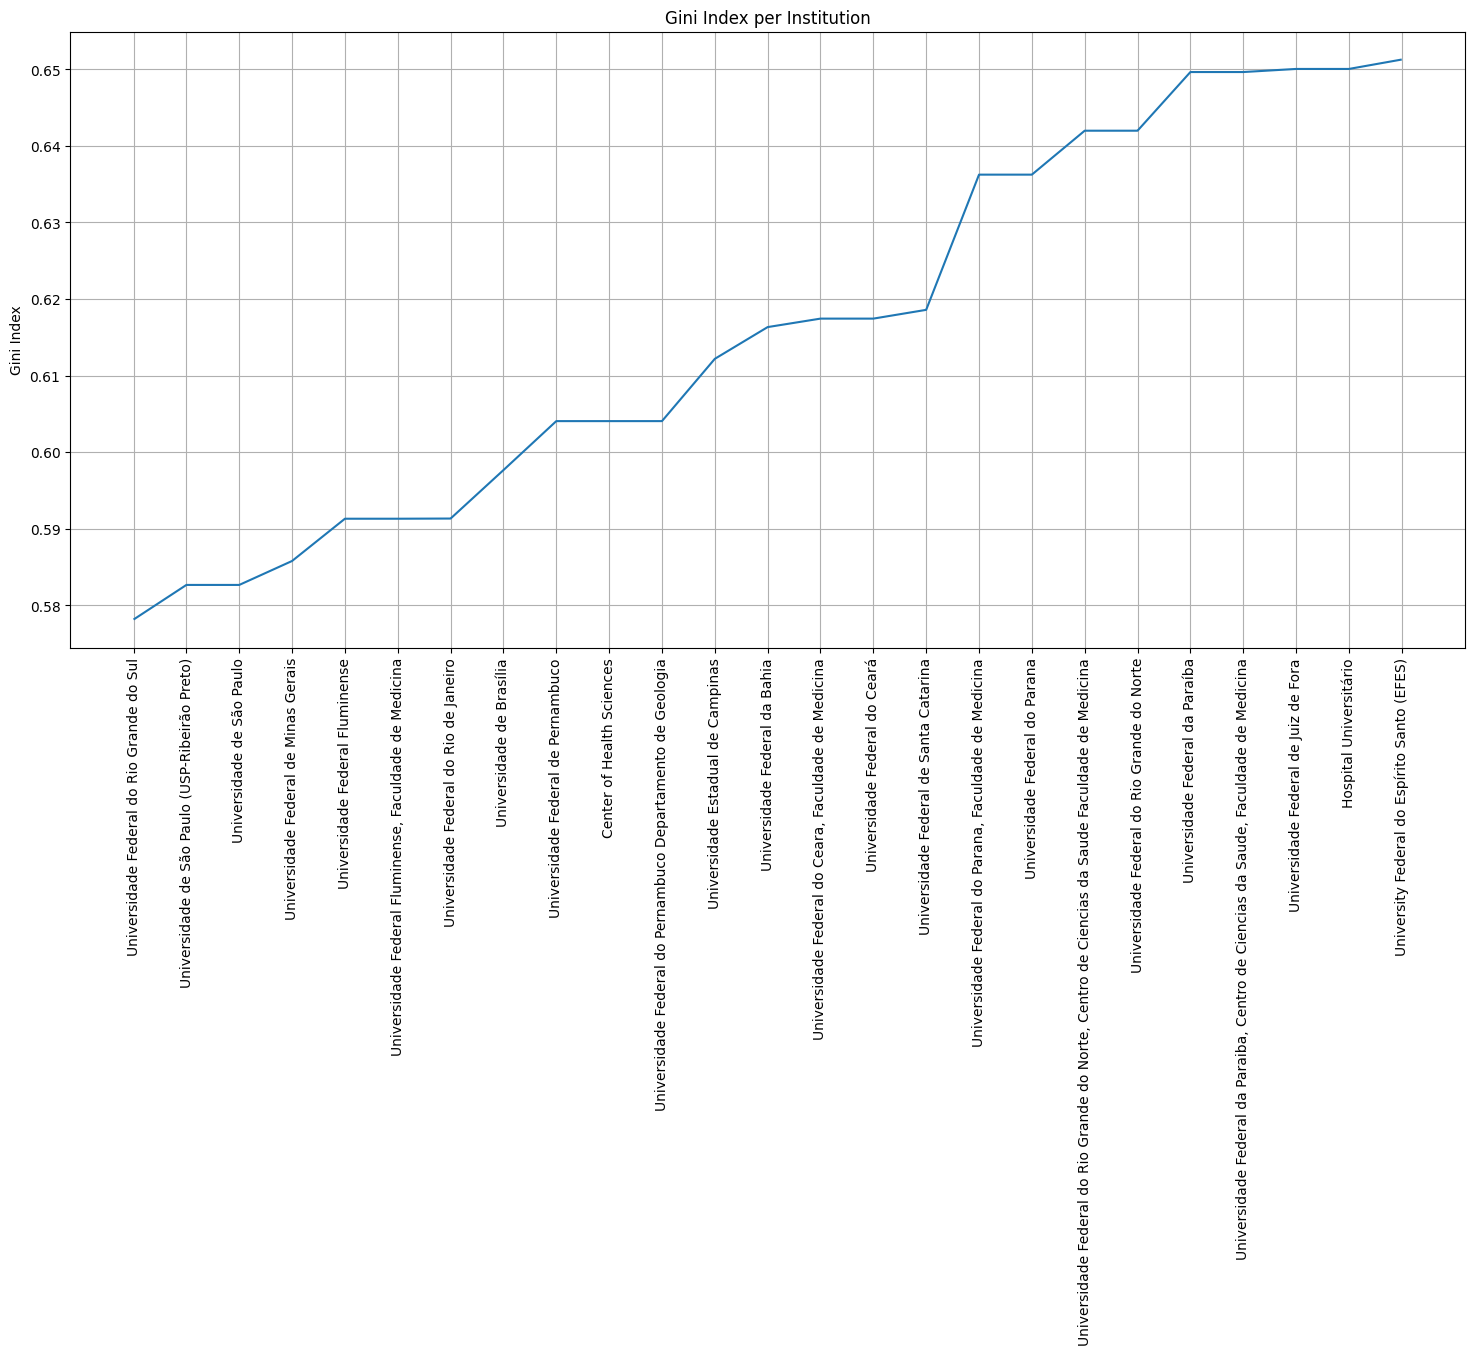

In [81]:
plt.figure(figsize=(18, 8))
plt.plot(di_table_subs['ins_name'].head(25), di_table_subs['gini_index'].head(25), linestyle=(0, (1, 0)))
plt.xticks(rotation=90, fontsize=10)  # rotate + smaller font
plt.ylabel('Gini Index')
plt.title('Gini Index per Institution')
plt.grid(True)
plt.show()



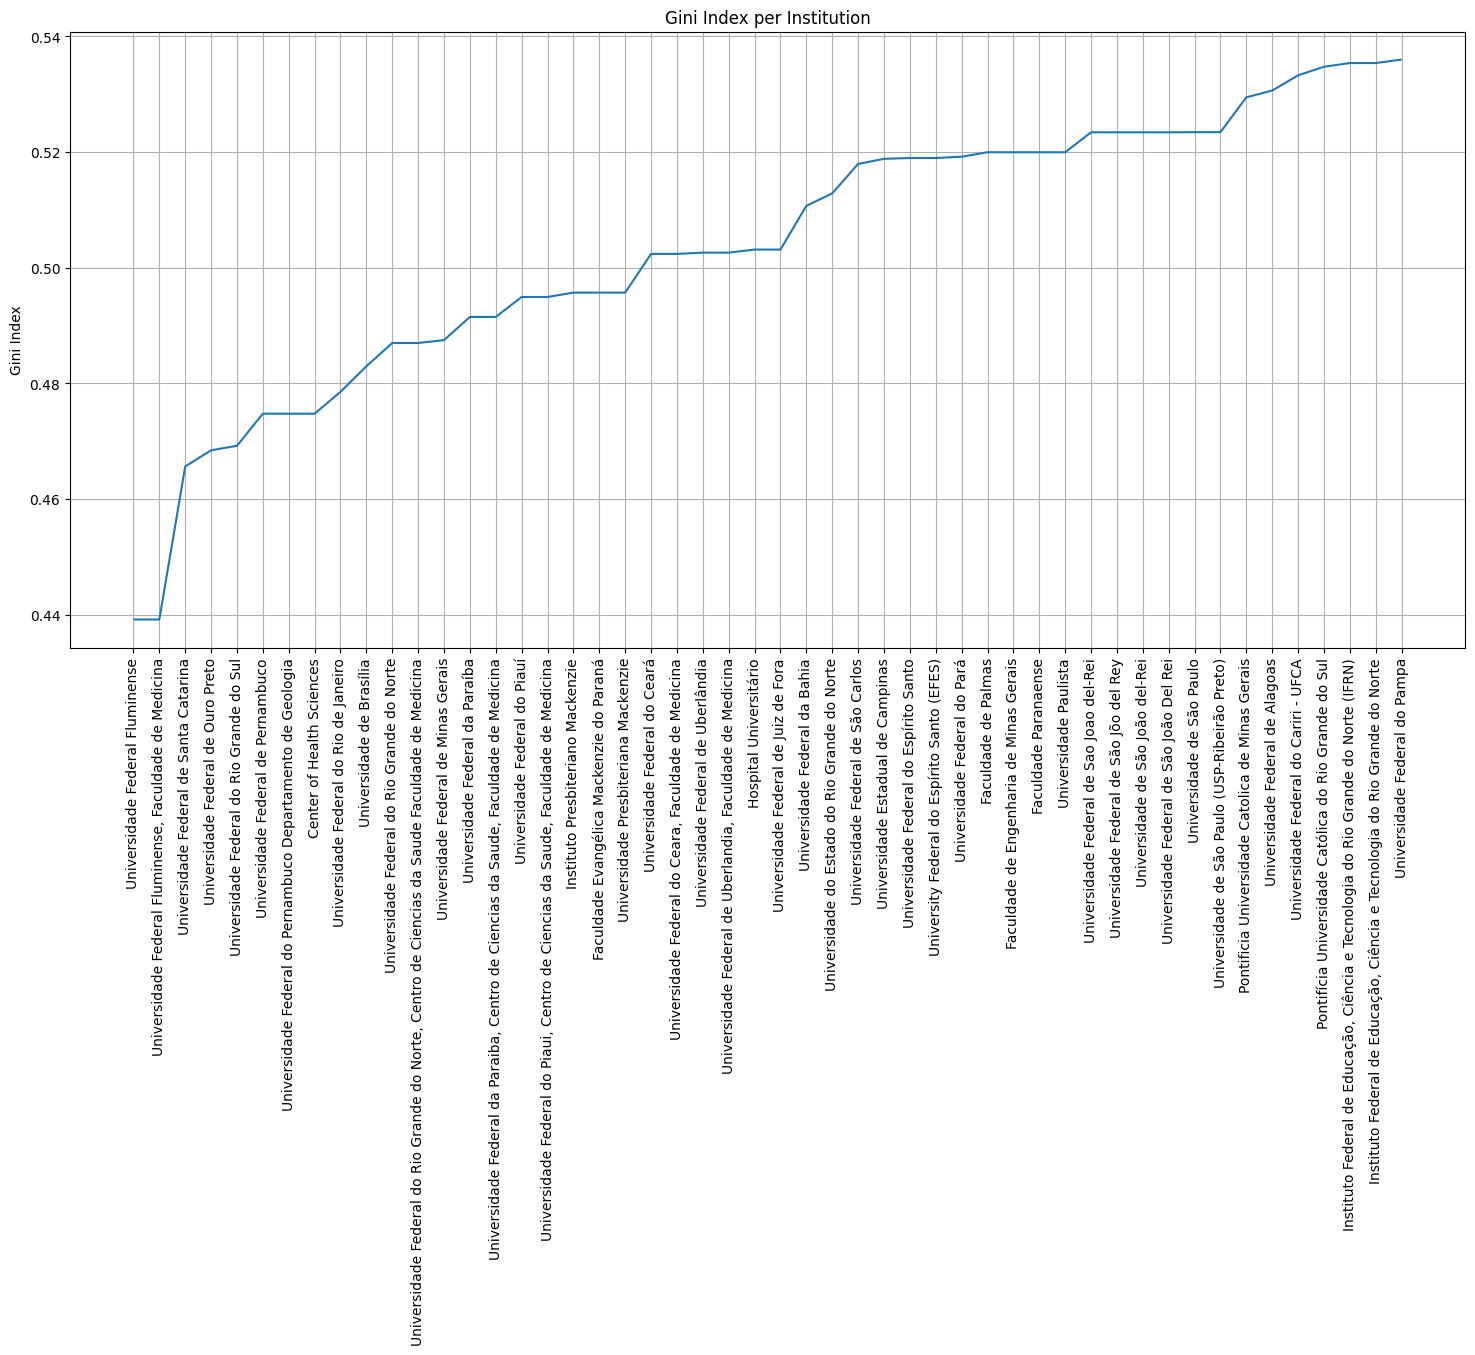

In [ ]:
plt.figure(figsize=(18, 8))
plt.plot(di_table_macros['ins_name'].head(50), di_table_macros['gini_index'].head(50), linestyle=(0, (1, 0)))
plt.xticks(rotation=90, fontsize=10)  # rotate + smaller font
plt.ylabel('Gini Index')
plt.title('Gini Index per Institution')
plt.grid(True)
plt.show()